# 03 — Training & Evaluation: Model Adaptif (XGBoost Regressor)

**Upgrade dari Decision Tree → XGBoost Regressor:**
- XGBoost lebih akurat dan robust untuk continuous prediction
- Optuna untuk hyperparameter tuning
- Comparison: DT (baseline) vs XGBoost

**Target metrics:**
- MAE < 0.04 (lebih ketat dari sebelumnya 0.05)
- R² > 0.90 (lebih ketat dari 0.85)

**Catatan:** Rule 3-cabang tetap **primary logic** di backend. XGBoost hanya untuk **fine-tune multiplier** (post-rule).

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
import os

from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)
os.makedirs('output/models', exist_ok=True)
os.makedirs('output/evaluation', exist_ok=True)

df = pd.read_parquet('output/preprocessed/replanning_dataset.parquet')
print(f'Loaded: {df.shape}')
df.head()

Loaded: (2773, 9)


,weekly_score,weight_diff_kg,bmi,experience_level,age,workout_frequency,strategy,rule_multiplier,target_multiplier
0,77.167142,-1.538895,30.20,3,56,4,MAINTAIN_SWAP,1.0,0.967
1,43.117357,-0.692923,32.00,2,46,4,REDUCE,0.7,0.658
2,61.476885,-0.527900,24.71,2,32,4,MAINTAIN_SWAP,1.0,1.040
3,40.230299,-0.504944,18.41,1,25,3,REDUCE,0.7,0.709
4,22.658466,-0.493198,14.39,1,38,3,REDUCE,0.7,0.667


In [2]:
# ── Feature & Target ──
FEATURES = ['weekly_score', 'weight_diff_kg', 'bmi', 'experience_level',
            'age', 'workout_frequency']
TARGET = 'target_multiplier'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (2218, 6), Test: (555, 6)


In [3]:
# ── BASELINE: Decision Tree Regressor ──
print('=== BASELINE: Decision Tree ===')
dt = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)
print(f'DT — MAE: {dt_mae:.4f} | R²: {dt_r2:.4f}')

=== BASELINE: Decision Tree ===
DT — MAE: 0.0263 | R²: 0.9642


In [4]:
# ── XGBoost dengan Optuna ──
print('=== OPTUNA: XGBoost Regressor ===')

def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('lr', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('depth', 3, 8),
        'n_estimators': trial.suggest_int('n_est', 100, 500, step=50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 2),
    }
    model = XGBRegressor(**params, random_state=42, n_jobs=-1, tree_method='hist')
    scores = cross_val_score(model, X_train, y_train, cv=5,
                              scoring='neg_mean_absolute_error', n_jobs=-1)
    return -scores.mean()  # MAE

study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)
print(f'\nBest MAE (CV): {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

=== OPTUNA: XGBoost Regressor ===


  0%|          | 0/30 [00:00<?, ?it/s]


Best MAE (CV): 0.0258
Best params: {'lr': 0.08374577922811874, 'depth': 6, 'n_est': 500, 'subsample': 0.9956952030582766, 'colsample': 0.6006598057902677, 'min_child': 5, 'gamma': 0.01845867705411243}


In [5]:
# ── Train Final XGBoost dengan best params ──
model_xgb = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1, tree_method='hist')
model_xgb.fit(X_train, y_train)

xgb_pred = model_xgb.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print('=== XGBoost Final ===')
print(f'MAE:  {xgb_mae:.4f} (target < 0.04)')
print(f'RMSE: {xgb_rmse:.4f}')
print(f'R²:   {xgb_r2:.4f} (target > 0.90)')

print(f'\n--- Comparison ---')
print(f'  DT      — MAE: {dt_mae:.4f} | R²: {dt_r2:.4f}')
print(f'  XGBoost — MAE: {xgb_mae:.4f} | R²: {xgb_r2:.4f}')
print(f'  Improvement: MAE {(dt_mae - xgb_mae):.4f} ({(dt_mae-xgb_mae)/dt_mae*100:+.1f}%)')
print()
print(f'  {"✅" if xgb_mae < 0.04 else "⚠️"} MAE target met')
print(f'  {"✅" if xgb_r2 > 0.90 else "⚠️"} R² target met')

=== XGBoost Final ===
MAE:  0.0258 (target < 0.04)
RMSE: 0.0328
R²:   0.9649 (target > 0.90)

--- Comparison ---
  DT      — MAE: 0.0263 | R²: 0.9642
  XGBoost — MAE: 0.0258 | R²: 0.9649
  Improvement: MAE 0.0004 (+1.7%)

  ✅ MAE target met
  ✅ R² target met


d:\Local Disk D\Tugas\hackathon core3d\machine-learning\notebook\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [10:14:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "colsample", "depth", "lr", "min_child", "n_est" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


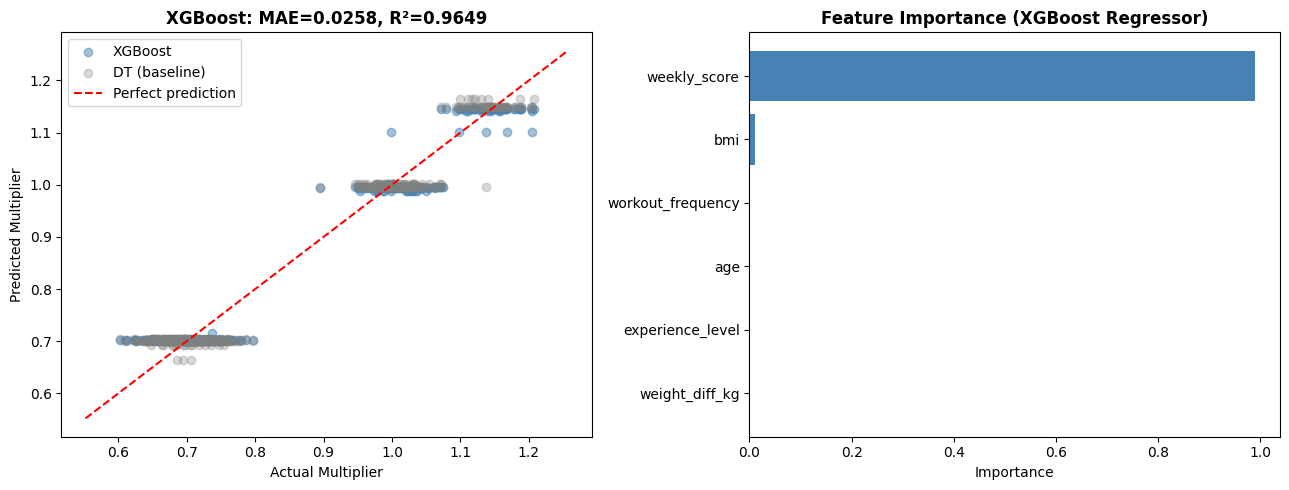

In [6]:
# ── Plots ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual
axes[0].scatter(y_test, xgb_pred, alpha=0.5, color='steelblue', label='XGBoost')
axes[0].scatter(y_test, dt_pred, alpha=0.3, color='gray', label='DT (baseline)')
lims = [min(y_test.min(), xgb_pred.min()) - 0.05,
        max(y_test.max(), xgb_pred.max()) + 0.05]
axes[0].plot(lims, lims, 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual Multiplier')
axes[0].set_ylabel('Predicted Multiplier')
axes[0].set_title(f'XGBoost: MAE={xgb_mae:.4f}, R²={xgb_r2:.4f}', fontweight='bold')
axes[0].legend()

# Feature importance
fi = model_xgb.feature_importances_
fi_df = pd.DataFrame({'feature': FEATURES, 'importance': fi}).sort_values('importance', ascending=True)
axes[1].barh(fi_df['feature'], fi_df['importance'], color='steelblue')
axes[1].set_title('Feature Importance (XGBoost Regressor)', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('output/evaluation/pred_vs_actual_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ── Save Models ──
joblib.dump(model_xgb, 'output/models/replanner_xgb.pkl', compress=3)
joblib.dump(dt, 'output/models/replanner_dt_baseline.pkl', compress=3)
joblib.dump(study, 'output/models/optuna_study_replanner.pkl', compress=3)

import os
size_kb = os.path.getsize('output/models/replanner_xgb.pkl') / 1024

metrics = {
    'xgboost': {
        'mae': round(float(xgb_mae), 4),
        'rmse': round(float(xgb_rmse), 4),
        'r2': round(float(xgb_r2), 4),
        'best_params': study.best_params,
        'model_size_kb': round(size_kb, 1),
    },
    'dt_baseline': {
        'mae': round(float(dt_mae), 4),
        'r2': round(float(dt_r2), 4),
    },
    'comparison': {
        'mae_improvement_pct': round(float((dt_mae - xgb_mae) / dt_mae * 100), 2),
    },
    'target_pass': {
        'mae_lt_0.04': bool(xgb_mae < 0.04),
        'r2_gt_0.90': bool(xgb_r2 > 0.90),
    },
    'note': 'Rule 3-cabang tetap primary di backend; XGBoost untuk fine-tune multiplier post-rule',
    'features': FEATURES,
    'target': TARGET,
}
with open('output/evaluation/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('✅ Selesai. Files saved:')
for f in sorted(os.listdir('output/models')):
    s = os.path.getsize(f'output/models/{f}') / 1024
    print(f'  output/models/{f:45s} ({s:.1f} KB)')

print('\n' + json.dumps(metrics, indent=2))

✅ Selesai. Files saved:
  output/models/optuna_study_replanner.pkl                    (8.9 KB)
  output/models/replanner_dt_baseline.pkl                     (1.3 KB)
  output/models/replanner_xgb.pkl                             (5.3 KB)

{
  "xgboost": {
    "mae": 0.0258,
    "rmse": 0.0328,
    "r2": 0.9649,
    "best_params": {
      "lr": 0.08374577922811874,
      "depth": 6,
      "n_est": 500,
      "subsample": 0.9956952030582766,
      "colsample": 0.6006598057902677,
      "min_child": 5,
      "gamma": 0.01845867705411243
    },
    "model_size_kb": 5.3
  },
  "dt_baseline": {
    "mae": 0.0263,
    "r2": 0.9642
  },
  "comparison": {
    "mae_improvement_pct": 1.69
  },
  "target_pass": {
    "mae_lt_0.04": true,
    "r2_gt_0.90": true
  },
  "note": "Rule 3-cabang tetap primary di backend; XGBoost untuk fine-tune multiplier post-rule",
  "features": [
    "weekly_score",
    "weight_diff_kg",
    "bmi",
    "experience_level",
    "age",
    "workout_frequency"
  ],
  "tar